# Solución de la Tarea: Coeficiente de Fricción y Formalismo de Green-Kubo
En este notebook se presenta la resolución de la tarea sobre el cálculo del coeficiente de fricción interfasial (denotado $\lambda$) empleando las variaciones temporales en la fuerza, según se desprende del formalismo de Green-Kubo. 

A continuación revisaremos un procedimiento paso a paso. Mantenemos el código simple, guiado y usando únicamente las lógicas detalladas durante la materia. 



## 1. Importación de Librerías
Comenzamos importando las dependencias base de Python que facilitan los cálculos posteriores.
* `numpy`: Permite el manejo de series numéricas, matrices y realizar transformadas de fourier eficientes (autocorrección).
* `scipy.integrate`: Nos permite realizar con facilidad la integral definida numéricamente a través de regla trapezoidal.
* `matplotlib.pyplot`: Herramienta gráfica por excelencia.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

## 2. Cargar los datos

In [2]:
ruta_data = "Force_reduce_eq.dat" # Ruta de la base de datos
data = np.loadtxt(ruta_data) # Cargar el archivo con Numpy

In [ ]:
# Obtener información previa de la data
print(np.info(data))
print("\n")
print(data)

class:  ndarray
shape:  (7326574, 4)
strides:  (32, 8)
itemsize:  8
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x2349620b040
byteorder:  little
byteswap:  False
type: float64
None


[[ 0.000000e+00  1.436210e+00 -2.181560e+00  1.720090e+03]
 [ 1.000000e+00  1.433640e+00 -2.178300e+00  1.721100e+03]
 [ 2.000000e+00  1.415270e+00 -2.188770e+00  1.715800e+03]
 ...
 [ 7.326571e+06 -1.929990e+00  8.943450e-01  1.194740e+01]
 [ 7.326572e+06 -1.993720e+00  8.684610e-01  1.251800e+01]
 [ 7.326573e+06 -2.054940e+00  8.198740e-01  1.298360e+01]]


In [9]:
# Eliminar los primeros 500 000 datos
inicio_equilibrio = 500000
datos_eq = data[inicio_equilibrio:]
print(np.info(datos_eq))

class:  ndarray
shape:  (6826574, 4)
strides:  (32, 8)
itemsize:  8
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x2349714d440
byteorder:  little
byteswap:  False
type: float64
None


## 3. Preparación de Constantes, factor de conversión a SI y conversión de las Fuerzas en *x* y *y*

In [10]:
# Se establecen las diferentes constantes del fluido en la nanoescala
kB = 1.380649e-23  # Constante de Boltzmann en [J/K]
T  = 300.0         # Temperatura [K]
dt = 1e-15         # Paso de tiempo [s]

# Dimensiones de la caja de simulación
Lx = 19.648e-10    # [m] = 19.648 Angstrom
Ly = 19.143e-10    # [m] = 19.143 Angstrom
A  = Lx * Ly       # Área interfasial [m2]

# Factor de conversión de fuerzas: (kcal/mol)/Angstrom → Newtons
# 1 kcal = 4184 J
# 1 mol = 6.02214076×10^(23) moléculas
# 1 Angstrom = 1×10^(-10) m
conv_fuerza = 4184.0 / (6.02214076e23 * 1e-10)

# Constante agrupada teórica antes de la integral temporal:
factor_gk = 1.0 / (A * kB * T)

# Como hay 4 columnas, la estructura es: [tiempo, Fx, Fy, Fz]
# Convertimos las fuerzas Fx y Fy a N
Fx = datos_eq[:, 1] * conv_fuerza
Fy = datos_eq[:, 2] * conv_fuerza


## 4. Obtención de Autocorrelación de la Función y Cota Numérica
Para disminuir la distorsión del error asociado, utilizamos una técnica de subdivisión donde particionamos la serie de datos en sub-bloques autónomos o intervalos (5 en este caso) sin solapar para luego sacar un promedio no correlacionado. 
A su vez, calcularemos la Función de Autocorrelación de la fuerza.



In [ ]:
# Algoritmo de extracción de ACF aplicando la Transformada Rápida de Fourier
seccion = 5000
numero_secciones = len(Fx) // seccion
print(f"Se procesarán {numero_secciones} secciones de {seccion} puntos")

# Función de autocorrelación según especificación del curso
def autocorr(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size//2:]

# Generar un registro por variable de dirección para capturar cada intervalo
lista_acf_x = []
lista_acf_y = []

# Iteración por el rango para estimaciones separadas
for i in range(numero_secciones):
    rango_in = i * seccion
    rango_fn = (i + 1) * seccion
    # C álculo de autocorrelación para cada seccion de datos
    acf_x = autocorr(Fx[rango_in:rango_fn]) 
    acf_y = autocorr(Fy[rango_in:rango_fn])
    # Almacenaje en una lista
    lista_acf_x.append(acf_x)
    lista_acf_y.append(acf_y)

# Apilar las ACFs de todas las secciones en un array 2D para promediar
array_acf_x = np.array(lista_acf_x)
array_acf_y = np.array(lista_acf_y)

promedio_x = np.mean(array_acf_x, axis=0)
promedio_y = np.mean(array_acf_y, axis=0)

# El Error Standard es aplicable para calcular la incertidumbre utilizando ddof=1
error_estandar_x = np.std(array_acf_x, axis=0, ddof=1) / np.sqrt(numero_secciones)
error_estandar_y = np.std(array_acf_y, axis=0, ddof=1) / np.sqrt(numero_secciones)

# Base de tiempos referencial por fts para visualizar
tiempo = np.arange(seccion)

Se procesarán 1365 secciones de 5000 puntos


## 5. El Coeficiente Numérico de la Fricción $\lambda$
Sabiendo que el ruido estadístico ensucia a las métricas del formalismo si analizamos tiempos inmensos, definimos $\tau$ para evitar tales varianzas usando cruces de signos nulos como limitación de estabilización. Posteriormente, empleamos integración por fraccionamiento para un comportamiento convergente y la zona aproximada a "Plateau".



In [13]:
# Definición analítica base de prefactor con tiempos
factor_final_int = factor_gk * dt

# Calcular por el método trapezoidal cumulativo la integración para ambas fuerzas 
lam_acumulada_x = cumulative_trapezoid(promedio_x, dx=1, initial=0) * factor_final_int
lam_acumulada_y = cumulative_trapezoid(promedio_y, dx=1, initial=0) * factor_final_int

# Incorporación progresiva de la incertidumbre al trapecio
err_lam_x = np.sqrt(cumulative_trapezoid(error_estandar_x**2, dx=1, initial=0)) * factor_final_int
err_lam_y = np.sqrt(cumulative_trapezoid(error_estandar_y**2, dx=1, initial=0)) * factor_final_int

# Ubicador del Límite Estacionario: Punto cero (o 20%) de ACF
def obtener_cruce_tau(acf, aproximacion=0.20):
    cruces = np.where(np.diff(np.sign(acf)))[0]
    if len(cruces) > 0:
        return int(cruces[0])
    return int(len(acf) * aproximacion)

tau_x = obtener_cruce_tau(promedio_x)
tau_y = obtener_cruce_tau(promedio_y)

# Localizando el segmento plano constante donde obtener el valor (Plateau)
plateau_x = slice(tau_x, min(int(1.5 * tau_x), len(lam_acumulada_x)))
plateau_y = slice(tau_y, min(int(1.5 * tau_y), len(lam_acumulada_y)))

# Determinando lambda definitivo finalizando promedios de meseta central
coef_lam_x = np.mean(lam_acumulada_x[plateau_x])
coef_lam_y = np.mean(lam_acumulada_y[plateau_y])

incert_lam_x = np.mean(err_lam_x[plateau_x])
incert_lam_y = np.mean(err_lam_y[plateau_y])

print("==== Resultados Finales Green-Kubo ====")
print(f" -> Coeficiente Fricción X (ZZ): {coef_lam_x:.2e} +/- {incert_lam_x:.2e} kg/(m2*s)")
print(f" -> Coeficiente Fricción Y (AC): {coef_lam_y:.2e} +/- {incert_lam_y:.2e} kg/(m2*s)")



==== Resultados Finales Green-Kubo ====
 -> Coeficiente Fricción X (ZZ): 2.70e+08 +/- 3.90e+05 kg/(m2*s)
 -> Coeficiente Fricción Y (AC): 2.77e+08 +/- 3.59e+05 kg/(m2*s)


## 6. Curvas Visualizadas y Análisis Acumulativo
Comportamiento final gráfico de nuestras métricas expuestas para confirmar que existió una meseta central (Plateau) esperada logrando valores aproximados a la teoría de fluidos.



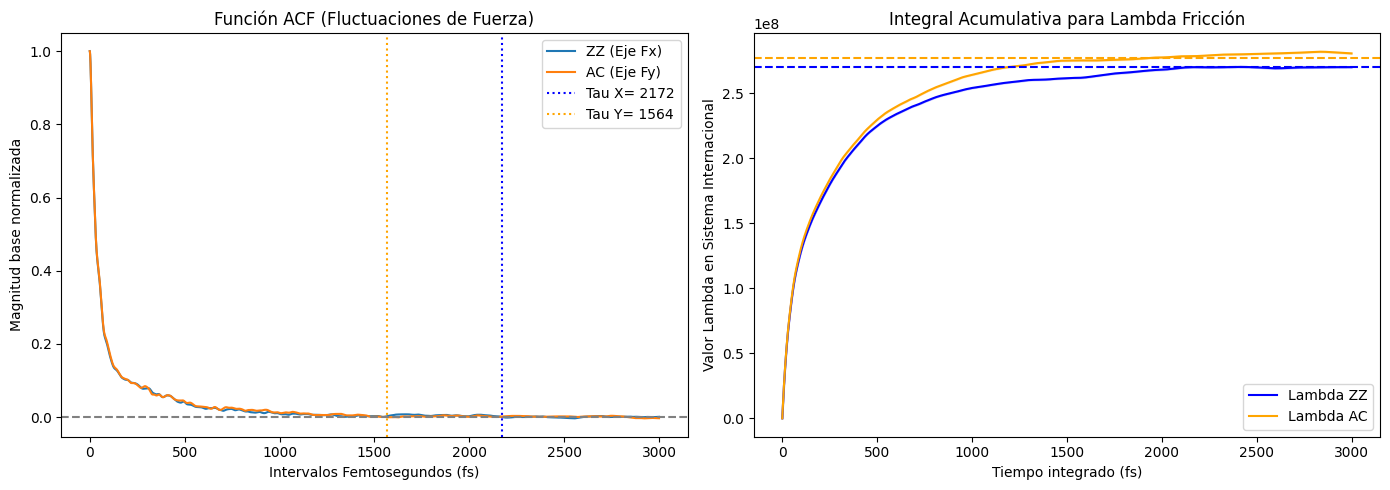

In [14]:
# Longitud temporal representativa a modo gráfico (Ej, 3000 fs)
visual = 3000

# Se divide por la cabecera (Normalizada)
acfn_x = promedio_x / promedio_x[0]
acfn_y = promedio_y / promedio_y[0]

figura, metricas = plt.subplots(1, 2, figsize=(14, 5))

# Representando Función de Autocorrelación Cortada
metricas[0].plot(tiempo[:visual], acfn_x[:visual], label="ZZ (Eje Fx)")
metricas[0].plot(tiempo[:visual], acfn_y[:visual], label="AC (Eje Fy)")
metricas[0].axhline(0, color="gray", linestyle="--", linewidth=1.5)
metricas[0].axvline(tau_x, color="blue", linestyle=":", label=f"Tau X= {tau_x}")
metricas[0].axvline(tau_y, color="orange", linestyle=":", label=f"Tau Y= {tau_y}")

metricas[0].legend()
metricas[0].set_title("Función ACF (Fluctuaciones de Fuerza)")
metricas[0].set_xlabel("Intervalos Femtosegundos (fs)")
metricas[0].set_ylabel("Magnitud base normalizada")

# Representando Estabilización y Cumulativa Lambda con sombreados de Incertidumbre
metricas[1].plot(tiempo[:visual], lam_acumulada_x[:visual], color="blue", label="Lambda ZZ")
metricas[1].fill_between(tiempo[:visual], 
                         (lam_acumulada_x - err_lam_x)[:visual], 
                         (lam_acumulada_x + err_lam_x)[:visual], color="blue", alpha=0.2)

metricas[1].plot(tiempo[:visual], lam_acumulada_y[:visual], color="orange", label="Lambda AC")
metricas[1].fill_between(tiempo[:visual], 
                         (lam_acumulada_y - err_lam_y)[:visual], 
                         (lam_acumulada_y + err_lam_y)[:visual], color="orange", alpha=0.2)

metricas[1].axhline(coef_lam_x, color="blue", linestyle="--")
metricas[1].axhline(coef_lam_y, color="orange", linestyle="--")

metricas[1].legend()
metricas[1].set_title("Integral Acumulativa para Lambda Fricción")
metricas[1].set_xlabel("Tiempo integrado (fs)")
metricas[1].set_ylabel("Valor Lambda en Sistema Internacional")

plt.tight_layout()
plt.show()

